In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import json  
import numpy as np  

In [2]:
KERNEL = np.ones((5, 5), np.uint8)

In [3]:
def return_parent_contours(contours, hierarchy):
    contours_parent = [contours[i] for i in range(len(contours)) if hierarchy[0][i][3] == -1]
    return contours_parent

def return_contours_of_interested_region(region_pre_p, pixel, min_area=0.0002):

    # pixels of images are identified by 5
    if len(region_pre_p.shape) == 3:
        cnts_images = (region_pre_p[:, :, 0] == pixel) * 1
    else:
        cnts_images = (region_pre_p[:, :] == pixel) * 1
    cnts_images = cnts_images.astype(np.uint8)
    cnts_images = np.repeat(cnts_images[:, :, np.newaxis], 3, axis=2)
    imgray = cv2.cvtColor(cnts_images, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(imgray, 0, 255, 0)

    contours_imgs, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    #print(len(contours_imgs), hierarchy)

    contours_imgs = return_parent_contours(contours_imgs, hierarchy)
    
    #print(len(contours_imgs), "iki")
    #contours_imgs = filter_contours_area_of_image_tables(thresh, contours_imgs, hierarchy, max_area=1, min_area=min_area)

    return contours_imgs


def update_region_contours(co_text, img_boundary, erosion_rate, dilation_rate, y_len, x_len, dilation_early=None, erosion_early=None):
    co_text_eroded = []
    for con in co_text:
        img_boundary_in = np.zeros( (y_len,x_len) )
        img_boundary_in = cv2.fillPoly(img_boundary_in, pts=[con], color=(1, 1, 1))
        
        if dilation_early:
            img_boundary_in = cv2.dilate(img_boundary_in[:,:], KERNEL, iterations=dilation_early)
            
        if erosion_early:
            img_boundary_in = cv2.erode(img_boundary_in[:,:], KERNEL, iterations=erosion_early)
        
        #img_boundary_in = cv2.erode(img_boundary_in[:,:], KERNEL, iterations=7)#asiatica
        if erosion_rate > 0:
            img_boundary_in = cv2.erode(img_boundary_in[:,:], KERNEL, iterations=erosion_rate)
        
        pixel = 1
        min_size = 0
        
        img_boundary_in =  img_boundary_in.astype("uint8")
        
        con_eroded = return_contours_of_interested_region(img_boundary_in,pixel, min_size )
        
        #try:
        co_text_eroded.append(con_eroded[0])
        #except:
            #co_text_eroded.append(con)
        

        img_boundary_in_dilated = cv2.dilate(img_boundary_in[:,:], KERNEL, iterations=dilation_rate)
        #img_boundary_in_dilated = cv2.dilate(img_boundary_in[:,:], KERNEL, iterations=5)
        
        boundary = img_boundary_in_dilated[:,:] - img_boundary_in[:,:]
        
        img_boundary[:,:][boundary[:,:]==1] =1
    return co_text_eroded, img_boundary

In [4]:
"""
colors = {
    "2d": {
        "paragraph": (1, 1, 1),
        "image": (2, 2, 2),
        "separator": (3, 3, 3),
        "artificial": (4, 4, 4),
    }}
"""

'\ncolors = {\n    "2d": {\n        "paragraph": (1, 1, 1),\n        "image": (2, 2, 2),\n        "separator": (3, 3, 3),\n        "artificial": (4, 4, 4),\n    }}\n'

In [5]:
"""
# full layout color 

colors = {
    "2d": {
        "paragraph": (1, 1, 1),
        "dropcapital": (3, 3, 3),
        "header": (2, 2, 2)
    }}
"""

'\n# full layout color \n\ncolors = {\n    "2d": {\n        "paragraph": (1, 1, 1),\n        "dropcapital": (3, 3, 3),\n        "header": (2, 2, 2)\n    }}\n'

In [6]:
"""
# page

colors = {
    "2d": {
        "page": (1, 1, 1)
    }}
"""

'\n# page\n\ncolors = {\n    "2d": {\n        "page": (1, 1, 1)\n    }}\n'

In [7]:
"""
# early layout with artificial class
colors = {
    "2d": {
        "textregion": (1, 1, 1),
        "imageregion": (2, 2, 2),
        "separatorregion": (3, 3, 3),
        "artificial": (4, 4, 4),
    }}
"""

'\n# early layout with artificial class\ncolors = {\n    "2d": {\n        "textregion": (1, 1, 1),\n        "imageregion": (2, 2, 2),\n        "separatorregion": (3, 3, 3),\n        "artificial": (4, 4, 4),\n    }}\n'

In [8]:

# textline with artificial class
colors = {
    "2d": {
        "textline": (1, 1, 1),
        "artificial": (2, 2, 2),
    }}

In [9]:
#dir_out = "/home/vahid/Downloads/marias_images/labels"
#dir_out = "/home/vahid/Documents/drop_capital_samples/new_gt_labelme/labels"
#dir_out = "/home/vahid/Downloads/27112366-batch-0/labels"
#dir_out = "/home/vahid/Documents/Layout-Auswertung/gt_made_with_labelme/labels"
dir_out = "/home/vahid/Documents/Layout-Auswertung/textlines/labels_json"

In [10]:
#dir_json = "/home/vahid/Downloads/marias_images/jsons"
#dir_json = "/home/vahid/Documents/drop_capital_samples/new_gt_labelme/jsons"
#dir_json = "/home/vahid/Downloads/27112366-batch-0/annotations"
#dir_json = "/home/vahid/Documents/Layout-Auswertung/gt_made_with_labelme/jsons"
dir_json = "/home/vahid/Documents/Layout-Auswertung/textlines/jsons"

In [11]:
ls_jsons = os.listdir(dir_json)

In [12]:
"""
for ind_json in ls_jsons:
    file_name = ind_json.split('.')[0]
    dir_single_json = os.path.join(dir_json, ind_json)
    
    with open(dir_single_json) as f:
        data = json.load(f)
        size = {
            "height": int(data["imageHeight"]),
            "width": int(data["imageWidth"])
        }
        
    co_text = []
    co_sep = []
    co_imgs = []

    for key in data["shapes"]:
        points = np.array(key["points"], dtype=np.int32)

        # Get the label and check if it exists in colors  
        label = key["label"]

        if label=="paragraph":
            co_text.append(points)
        if label=="image":
            co_imgs.append(points)

        if label=="separator":
            co_sep.append(points)
        #if label in colors["2d"]:  # Check for 2d or 3d  
        #    cv2.fillPoly(image, pts=[points], color=colors['2d'][label])
        
        
    img_boundary = np.zeros( (size["height"], size["width"]) )
    erosion_rate = 1
    dilation_rate = 3
    co_text, img_boundary = update_region_contours(co_text, img_boundary, erosion_rate, dilation_rate, size["height"], size["width"] )


    image = np.zeros((size["height"], size["width"], 3), np.uint8)

    cv2.fillPoly(image, pts =co_imgs, color=colors['2d']["image"])
    cv2.fillPoly(image, pts =co_text, color=colors['2d']["paragraph"])
    image[:,:][img_boundary[:,:]==1] = 4
    cv2.fillPoly(image, pts =co_sep, color=colors['2d']["separator"])

    cv2.imwrite(os.path.join(dir_out, file_name+'.png'), image)
    
"""

'\nfor ind_json in ls_jsons:\n    file_name = ind_json.split(\'.\')[0]\n    dir_single_json = os.path.join(dir_json, ind_json)\n    \n    with open(dir_single_json) as f:\n        data = json.load(f)\n        size = {\n            "height": int(data["imageHeight"]),\n            "width": int(data["imageWidth"])\n        }\n        \n    co_text = []\n    co_sep = []\n    co_imgs = []\n\n    for key in data["shapes"]:\n        points = np.array(key["points"], dtype=np.int32)\n\n        # Get the label and check if it exists in colors  \n        label = key["label"]\n\n        if label=="paragraph":\n            co_text.append(points)\n        if label=="image":\n            co_imgs.append(points)\n\n        if label=="separator":\n            co_sep.append(points)\n        #if label in colors["2d"]:  # Check for 2d or 3d  \n        #    cv2.fillPoly(image, pts=[points], color=colors[\'2d\'][label])\n        \n        \n    img_boundary = np.zeros( (size["height"], size["width"]) )\n    

In [13]:
"""
## full layout case

for ind_json in ls_jsons:
    file_name = ind_json.split('.')[0]
    dir_single_json = os.path.join(dir_json, ind_json)
    
    with open(dir_single_json) as f:
        data = json.load(f)
        size = {
            "height": int(data["imageHeight"]),
            "width": int(data["imageWidth"])
        }
        
    co_text = []
    co_drop = []
    co_head = []

    for key in data["shapes"]:
        points = np.array(key["points"], dtype=np.int32)

        # Get the label and check if it exists in colors  
        label = key["label"]

        if label=="paragraph":
            co_text.append(points)
        if label=="dropcapital":
            co_drop.append(points)

        if label=="header":
            co_head.append(points)
        #if label in colors["2d"]:  # Check for 2d or 3d  
        #    cv2.fillPoly(image, pts=[points], color=colors['2d'][label])
        
        
    print(co_text)
    print(colors['2d']["paragraph"])
    img_boundary = np.zeros( (size["height"], size["width"]) )

    image = np.zeros((size["height"], size["width"], 3), np.uint8)

    cv2.fillPoly(image, pts =co_head, color=colors['2d']["header"])
    cv2.fillPoly(image, pts =co_text, color=colors['2d']["paragraph"])
    cv2.fillPoly(image, pts =co_drop, color=colors['2d']["dropcapital"])

    cv2.imwrite(os.path.join(dir_out, file_name+'.png'), image)
    
"""

'\n## full layout case\n\nfor ind_json in ls_jsons:\n    file_name = ind_json.split(\'.\')[0]\n    dir_single_json = os.path.join(dir_json, ind_json)\n    \n    with open(dir_single_json) as f:\n        data = json.load(f)\n        size = {\n            "height": int(data["imageHeight"]),\n            "width": int(data["imageWidth"])\n        }\n        \n    co_text = []\n    co_drop = []\n    co_head = []\n\n    for key in data["shapes"]:\n        points = np.array(key["points"], dtype=np.int32)\n\n        # Get the label and check if it exists in colors  \n        label = key["label"]\n\n        if label=="paragraph":\n            co_text.append(points)\n        if label=="dropcapital":\n            co_drop.append(points)\n\n        if label=="header":\n            co_head.append(points)\n        #if label in colors["2d"]:  # Check for 2d or 3d  \n        #    cv2.fillPoly(image, pts=[points], color=colors[\'2d\'][label])\n        \n        \n    print(co_text)\n    print(colors[\'2

In [14]:
"""
## page extraction case

for ind_json in ls_jsons:
    file_name = ind_json.split('.')[0]
    dir_single_json = os.path.join(dir_json, ind_json)
    
    with open(dir_single_json) as f:
        data = json.load(f)
        size = {
            "height": int(data["imageHeight"]),
            "width": int(data["imageWidth"])
        }
        
    co_text = []

    for key in data["shapes"]:
        points = np.array(key["points"], dtype=np.int32)

        # Get the label and check if it exists in colors  
        label = key["label"]

        if label=="page":
            co_text.append(points)
        
        
    print(co_text)
    print(colors['2d']["page"])
    img_boundary = np.zeros( (size["height"], size["width"]) )

    image = np.zeros((size["height"], size["width"], 3), np.uint8)

    cv2.fillPoly(image, pts =co_text, color=colors['2d']["page"])

    cv2.imwrite(os.path.join(dir_out, file_name+'.png'), image)
"""

'\n## page extraction case\n\nfor ind_json in ls_jsons:\n    file_name = ind_json.split(\'.\')[0]\n    dir_single_json = os.path.join(dir_json, ind_json)\n    \n    with open(dir_single_json) as f:\n        data = json.load(f)\n        size = {\n            "height": int(data["imageHeight"]),\n            "width": int(data["imageWidth"])\n        }\n        \n    co_text = []\n\n    for key in data["shapes"]:\n        points = np.array(key["points"], dtype=np.int32)\n\n        # Get the label and check if it exists in colors  \n        label = key["label"]\n\n        if label=="page":\n            co_text.append(points)\n        \n        \n    print(co_text)\n    print(colors[\'2d\']["page"])\n    img_boundary = np.zeros( (size["height"], size["width"]) )\n\n    image = np.zeros((size["height"], size["width"], 3), np.uint8)\n\n    cv2.fillPoly(image, pts =co_text, color=colors[\'2d\']["page"])\n\n    cv2.imwrite(os.path.join(dir_out, file_name+\'.png\'), image)\n'

In [15]:
"""
## early layout with artificil class

for ind_json in ls_jsons:
    file_name = ind_json.split('.')[0]
    dir_single_json = os.path.join(dir_json, ind_json)
    
    with open(dir_single_json) as f:
        data = json.load(f)
        size = {
            "height": int(data["imageHeight"]),
            "width": int(data["imageWidth"])
        }
        
    co_text = []
    co_sep = []
    co_imgs = []

    for key in data["shapes"]:
        points = np.array(key["points"], dtype=np.int32)

        # Get the label and check if it exists in colors  
        label = key["label"]

        if label=="textregion":
            co_text.append(points)
        if label=="imageregion":
            co_imgs.append(points)

        if label=="separatorregion":
            co_sep.append(points)
        #if label in colors["2d"]:  # Check for 2d or 3d  
        #    cv2.fillPoly(image, pts=[points], color=colors['2d'][label])
        
        
    img_boundary = np.zeros( (size["height"], size["width"]) )
    erosion_rate = 1
    dilation_rate = 3
    co_text, img_boundary = update_region_contours(co_text, img_boundary, erosion_rate, dilation_rate, size["height"], size["width"] )


    image = np.zeros((size["height"], size["width"], 3), np.uint8)

    cv2.fillPoly(image, pts =co_imgs, color=colors['2d']["imageregion"])
    cv2.fillPoly(image, pts =co_text, color=colors['2d']["textregion"])
    image[:,:][img_boundary[:,:]==1] = 4
    cv2.fillPoly(image, pts =co_sep, color=colors['2d']["separatorregion"])

    cv2.imwrite(os.path.join(dir_out, file_name+'.png'), image)
"""

'\n## early layout with artificil class\n\nfor ind_json in ls_jsons:\n    file_name = ind_json.split(\'.\')[0]\n    dir_single_json = os.path.join(dir_json, ind_json)\n    \n    with open(dir_single_json) as f:\n        data = json.load(f)\n        size = {\n            "height": int(data["imageHeight"]),\n            "width": int(data["imageWidth"])\n        }\n        \n    co_text = []\n    co_sep = []\n    co_imgs = []\n\n    for key in data["shapes"]:\n        points = np.array(key["points"], dtype=np.int32)\n\n        # Get the label and check if it exists in colors  \n        label = key["label"]\n\n        if label=="textregion":\n            co_text.append(points)\n        if label=="imageregion":\n            co_imgs.append(points)\n\n        if label=="separatorregion":\n            co_sep.append(points)\n        #if label in colors["2d"]:  # Check for 2d or 3d  \n        #    cv2.fillPoly(image, pts=[points], color=colors[\'2d\'][label])\n        \n        \n    img_boundar

In [17]:

## textline with artificil class

for ind_json in ls_jsons:
    file_name = ind_json.split('.')[0]
    dir_single_json = os.path.join(dir_json, ind_json)
    
    with open(dir_single_json) as f:
        data = json.load(f)
        size = {
            "height": int(data["imageHeight"]),
            "width": int(data["imageWidth"])
        }
        
    co_textline = []

    for key in data["shapes"]:
        points = np.array(key["points"], dtype=np.int32)

        # Get the label and check if it exists in colors  
        label = key["label"]

        if label=="textline":
            co_textline.append(points)
        
        
    img_boundary = np.zeros( (size["height"], size["width"]) )
    erosion_rate = 1
    dilation_rate = 3
    co_textline, img_boundary = update_region_contours(co_textline, img_boundary, erosion_rate, dilation_rate, size["height"], size["width"] )


    image = np.zeros((size["height"], size["width"], 3), np.uint8)

    cv2.fillPoly(image, pts =co_textline, color=colors['2d']["textline"])
    image[:,:][img_boundary[:,:]==1] = 2

    cv2.imwrite(os.path.join(dir_out, file_name+'.png'), image)


In [18]:
label_ex = cv2.imread('/home/vahid/Documents/ulrike_ner_images/farsi_images/prepared_data/labels/SNP26687665-18981110-0-0-0-0_-003.png')

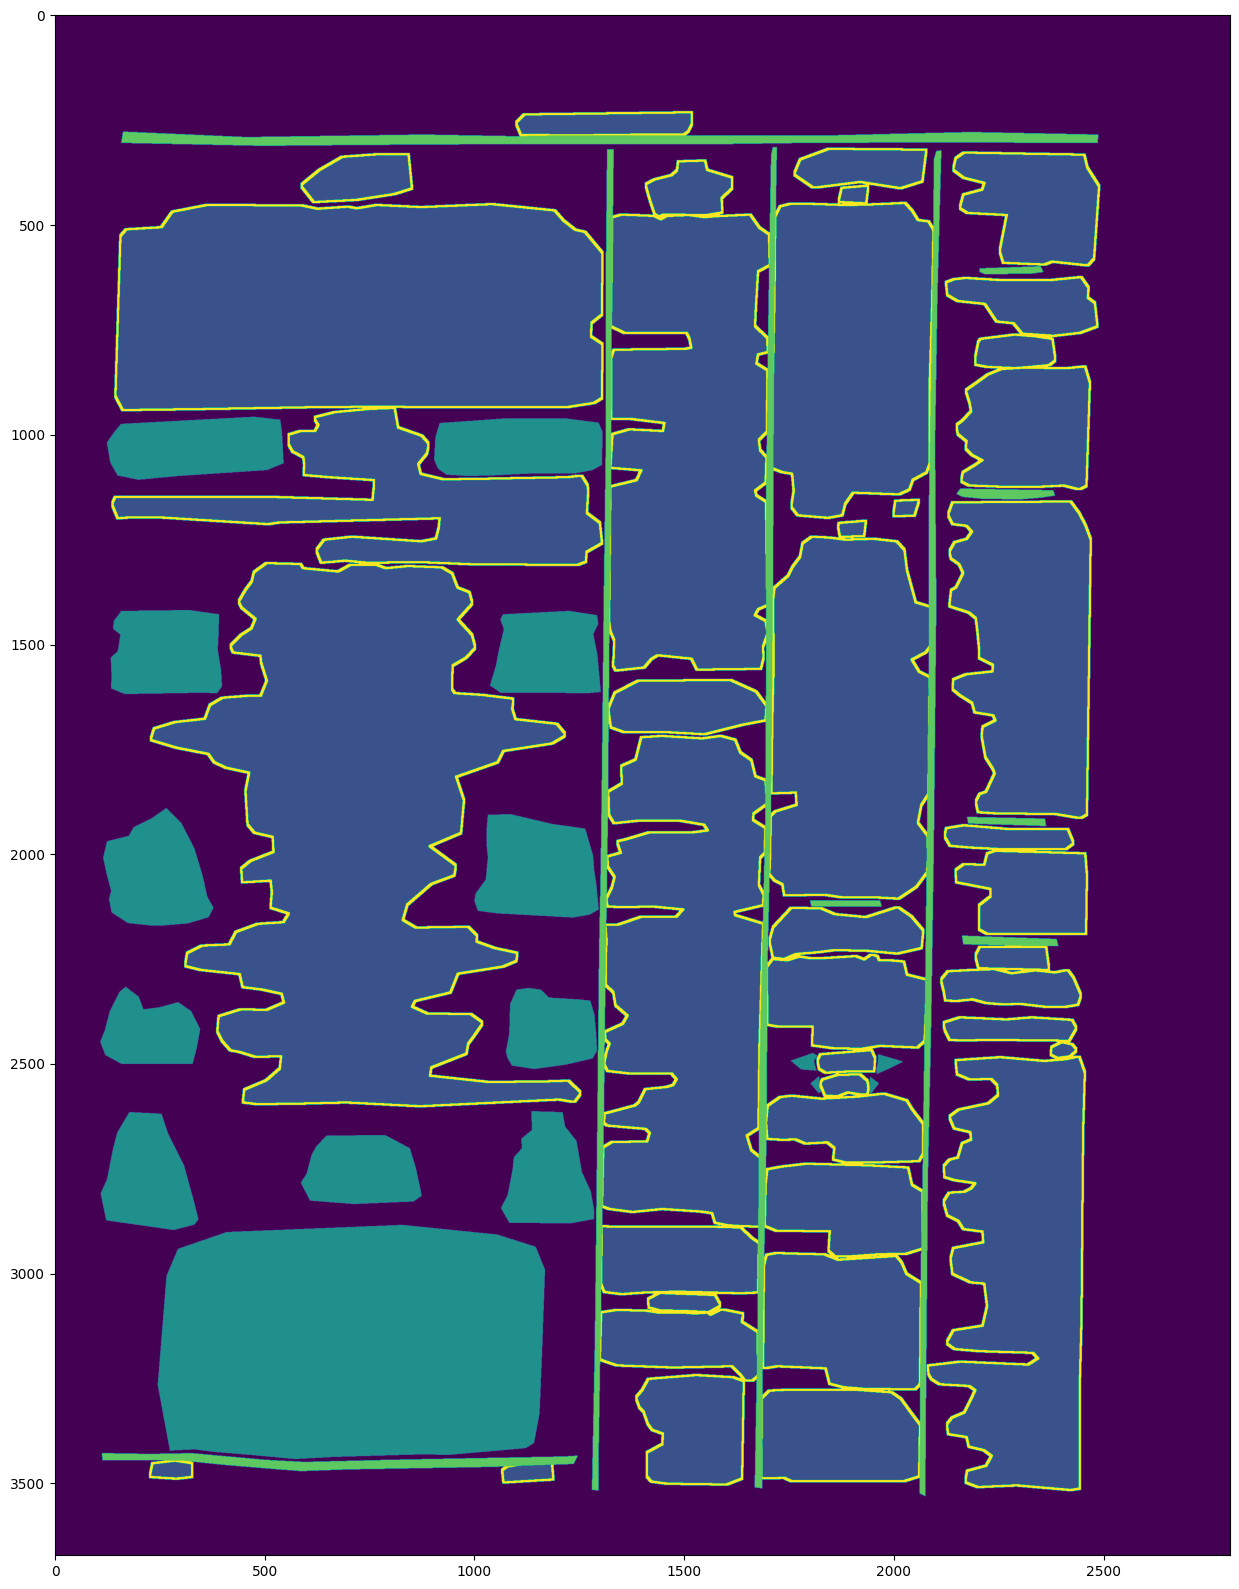

In [19]:
plt.figure(figsize=(20,20))
plt.imshow(label_ex[:,:,0])